# DATASET

In [3]:
print("Insurance Claim Risk Detection Project")

Insurance Claim Risk Detection Project


**CHECK THE DATASET**

In [4]:
import pandas as pd

df = pd.read_csv("/content/carclaims.csv")

df.head()


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


**DATASET SIZE**

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 15420
Columns: 33


**All column names**

In [6]:
df.columns


Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'PolicyNumber', 'RepNumber', 'Deductible',
       'DriverRating', 'Days:Policy-Accident', 'Days:Policy-Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars', 'Year',
       'BasePolicy', 'FraudFound'],
      dtype='object')

**DATSET INFO**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  PolicyNumber          15420 non-null

**DUPLICATES ROWS**

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Number of fraudulent vs genuine claims**

In [9]:
df["FraudFound"].value_counts()

,count
FraudFound,
No,14497
Yes,923


**Percentage of fraudulent vs genuine claims**

In [10]:
df["FraudFound"].value_counts(normalize=True) * 100


,proportion
FraudFound,
No,94.014267
Yes,5.985733


In [11]:
for column in df.columns:
    print("\n" + "=" * 50)
    print(column)
    print(df[column].unique()[:20])



Month
['Dec' 'Jan' 'Oct' 'Jun' 'Feb' 'Nov' 'Apr' 'Mar' 'Aug' 'Jul' 'May' 'Sep']

WeekOfMonth
[5 3 2 4 1]

DayOfWeek
['Wednesday' 'Friday' 'Saturday' 'Monday' 'Tuesday' 'Sunday' 'Thursday']

Make
['Honda' 'Toyota' 'Ford' 'Mazda' 'Chevrolet' 'Pontiac' 'Accura' 'Dodge'
 'Mercury' 'Jaguar' 'Nisson' 'VW' 'Saab' 'Saturn' 'Porche' 'BMW' 'Mecedes'
 'Ferrari' 'Lexus']

AccidentArea
['Urban' 'Rural']

DayOfWeekClaimed
['Tuesday' 'Monday' 'Thursday' 'Friday' 'Wednesday' 'Saturday' 'Sunday'
 '0']

MonthClaimed
['Jan' 'Nov' 'Jul' 'Feb' 'Mar' 'Dec' 'Apr' 'Aug' 'May' 'Jun' 'Sep' 'Oct'
 '0']

WeekOfMonthClaimed
[1 4 2 3 5]

Sex
['Female' 'Male']

MaritalStatus
['Single' 'Married' 'Widow' 'Divorced']

Age
[21 34 47 65 27 20 36  0 30 42 71 52 28 61 38 41 32 40 63 31]

Fault
['Policy Holder' 'Third Party']

PolicyType
['Sport - Liability' 'Sport - Collision' 'Sedan - Liability'
 'Utility - All Perils' 'Sedan - All Perils' 'Sedan - Collision'
 'Utility - Collision' 'Utility - Liability' 'Sport - All Peri

In [12]:
print("Age = 0:", (df["Age"] == 0).sum())


Age = 0: 320


**Check unusual values**

In [13]:
print("DayOfWeekClaimed = 0:",
      (df["DayOfWeekClaimed"] == "0").sum())

print("MonthClaimed = 0:",
      (df["MonthClaimed"] == "0").sum())

DayOfWeekClaimed = 0: 1
MonthClaimed = 0: 1


In [14]:
print("Age = 0:", (df["Age"] == 0).sum())

print(
    "DayOfWeekClaimed = 0:",
    (df["DayOfWeekClaimed"] == "0").sum()
)

print(
    "MonthClaimed = 0:",
    (df["MonthClaimed"] == "0").sum()
)

Age = 0: 320
DayOfWeekClaimed = 0: 1
MonthClaimed = 0: 1


**Clean these invalid values**

**FIX AGE = 0**

In [15]:
import numpy as np

df["Age"] = df["Age"].replace(0, np.nan)

**Handle DayOfWeekClaimed = "0"**

In [16]:
df["DayOfWeekClaimed"] = df["DayOfWeekClaimed"].replace("0", np.nan)

**Handle MonthClaimed = "0"**

In [17]:
df["MonthClaimed"] = df["MonthClaimed"].replace("0", np.nan)

**Verify cleaning**

In [18]:
print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after cleaning:
DayOfWeekClaimed      1
MonthClaimed          1
Age                 320
dtype: int64


**Remove the identifier**

In [19]:
df = df.drop(columns=["PolicyNumber"])

**Check cleaned dataset**

In [20]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 15420
Columns: 32


In [21]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nRemaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nPolicyNumber present:", "PolicyNumber" in df.columns)

Rows: 15420
Columns: 32

Remaining missing values:
DayOfWeekClaimed      1
MonthClaimed          1
Age                 320
dtype: int64

PolicyNumber present: False


**Prepare the target**

In [22]:
df["FraudFlag"] = df["FraudFound"].map({
    "No": 0,
    "Yes": 1
})

In [23]:
df[["FraudFound", "FraudFlag"]].head()



,FraudFound,FraudFlag
0,No,0
1,No,0
2,No,0
3,No,0
4,No,0


# EDA

**Create first visualization**

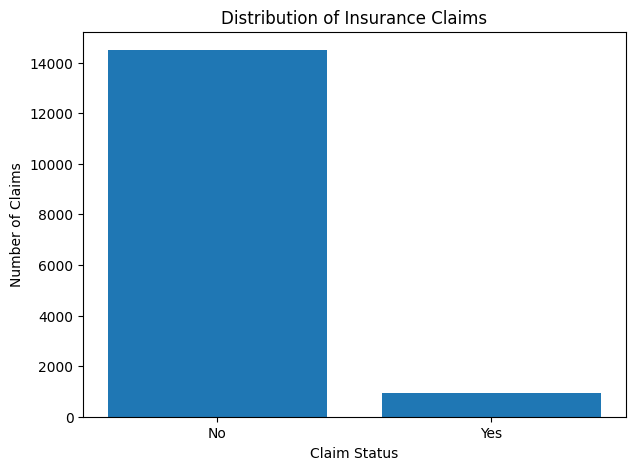

In [24]:
import matplotlib.pyplot as plt

fraud_counts = df["FraudFound"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(fraud_counts.index, fraud_counts.values)

plt.title("Distribution of Insurance Claims")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")

plt.show()

**Fraud rate by Accident Area**

In [25]:
fraud_by_area = (
    df.groupby("AccidentArea")["FraudFlag"]
    .mean()
    .mul(100)
    .reset_index(name="FraudRate")
)

fraud_by_area

,AccidentArea,FraudRate
0,Rural,8.322904
1,Urban,5.715526


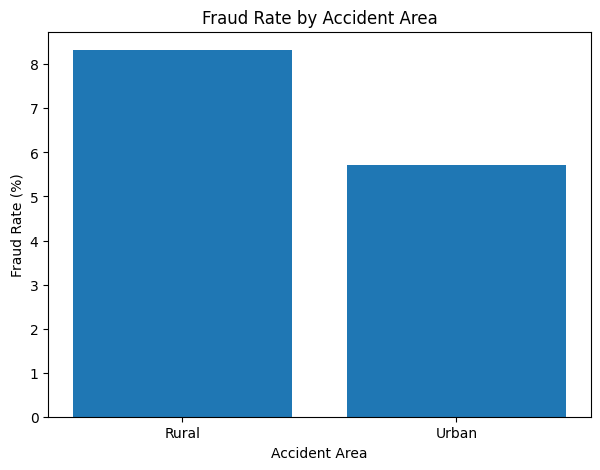

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    fraud_by_area["AccidentArea"],
    fraud_by_area["FraudRate"]
)

plt.title("Fraud Rate by Accident Area")
plt.xlabel("Accident Area")
plt.ylabel("Fraud Rate (%)")

plt.show()

**Fraud rate by Vehicle Category**

In [27]:
fraud_by_vehicle = (
    df.groupby("VehicleCategory")["FraudFlag"]
    .mean()
    .mul(100)
    .reset_index(name="FraudRate")
)

fraud_by_vehicle

,VehicleCategory,FraudRate
0,Sedan,8.220453
1,Sport,1.567749
2,Utility,11.253197


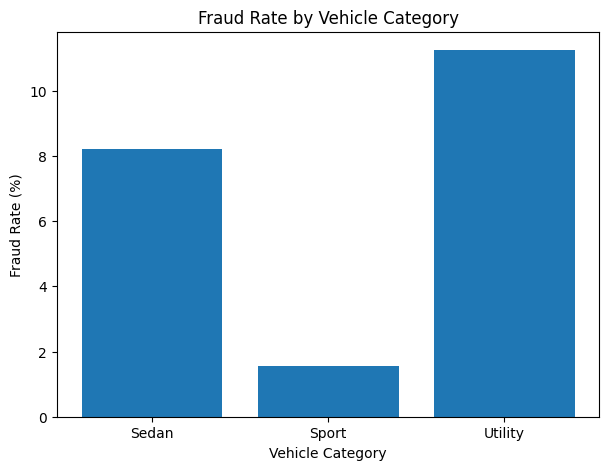

In [28]:
plt.figure(figsize=(7, 5))

plt.bar(
    fraud_by_vehicle["VehicleCategory"],
    fraud_by_vehicle["FraudRate"]
)

plt.title("Fraud Rate by Vehicle Category")
plt.xlabel("Vehicle Category")
plt.ylabel("Fraud Rate (%)")

plt.show()

**Fraud rate by Fault**

In [29]:
fraud_by_fault = (
    df.groupby("Fault")["FraudFlag"]
    .mean()
    .mul(100)
    .reset_index(name="FraudRate")
)

fraud_by_fault

,Fault,FraudRate
0,Policy Holder,7.889581
1,Third Party,0.883055


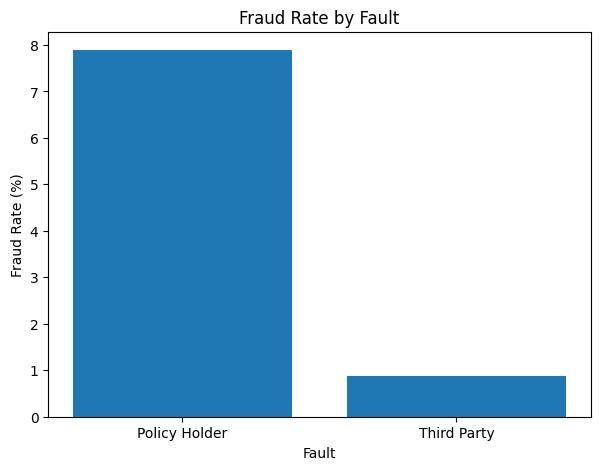

In [30]:
plt.figure(figsize=(7, 5))

plt.bar(
    fraud_by_fault["Fault"],
    fraud_by_fault["FraudRate"]
)

plt.title("Fraud Rate by Fault")
plt.xlabel("Fault")
plt.ylabel("Fraud Rate (%)")

plt.show()

**Fraud rate by Police Report**

In [31]:
fraud_by_police = (
    df.groupby("PoliceReportFiled")["FraudFlag"]
    .mean()
    .mul(100)
    .reset_index(name="FraudRate")
)

fraud_by_police


,PoliceReportFiled,FraudRate
0,No,6.049893
1,Yes,3.738318


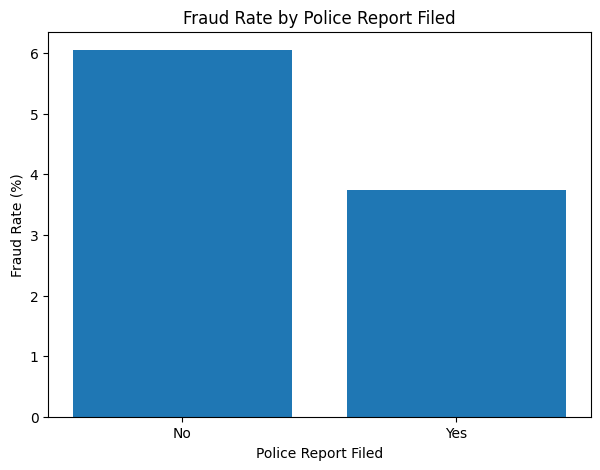

In [32]:
plt.figure(figsize=(7, 5))

plt.bar(
    fraud_by_police["PoliceReportFiled"],
    fraud_by_police["FraudRate"]
)

plt.title("Fraud Rate by Police Report Filed")
plt.xlabel("Police Report Filed")
plt.ylabel("Fraud Rate (%)")

plt.show()

**Create age groups**

In [33]:
age_df = df.dropna(subset=["Age"]).copy()

age_df["AgeGroup"] = pd.cut(
    age_df["Age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

fraud_by_age = (
    age_df.groupby("AgeGroup", observed=False)["FraudFlag"]
    .mean()
    .mul(100)
    .reset_index(name="FraudRate")
)

fraud_by_age

,AgeGroup,FraudRate
0,18-25,6.929348
1,26-35,6.436617
2,36-45,5.861984
3,46-55,5.091938
4,56-65,5.028736
5,66+,5.905512


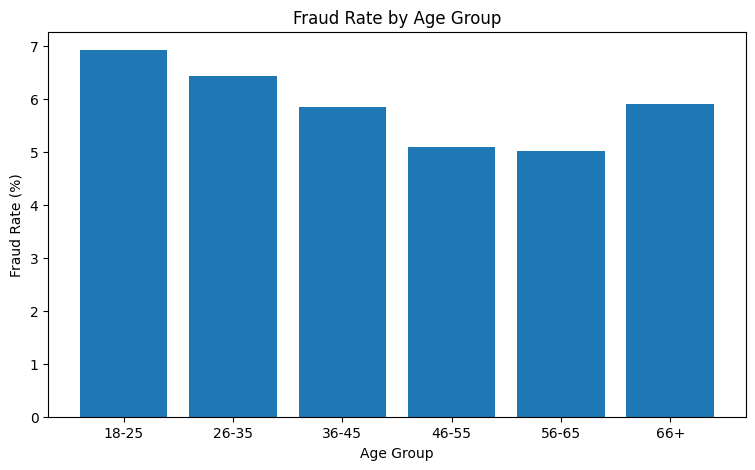

In [34]:
plt.figure(figsize=(9, 5))

plt.bar(
    fraud_by_age["AgeGroup"].astype(str),
    fraud_by_age["FraudRate"]
)

plt.title("Fraud Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate (%)")

plt.show()

**Fraud rate by Policy Type**

In [35]:
fraud_by_policy = (
    df.groupby("PolicyType")["FraudFlag"]
    .mean()
    .mul(100)
    .reset_index(name="FraudRate")
    .sort_values("FraudRate", ascending=False)
)

fraud_by_policy

,PolicyType,FraudRate
4,Sport - Collision,13.793103
6,Utility - All Perils,12.058824
0,Sedan - All Perils,10.056276
7,Utility - Collision,10.000000
1,Sedan - Collision,6.876791
2,Sedan - Liability,0.721877
3,Sport - All Perils,0.000000
5,Sport - Liability,0.000000
8,Utility - Liability,0.000000


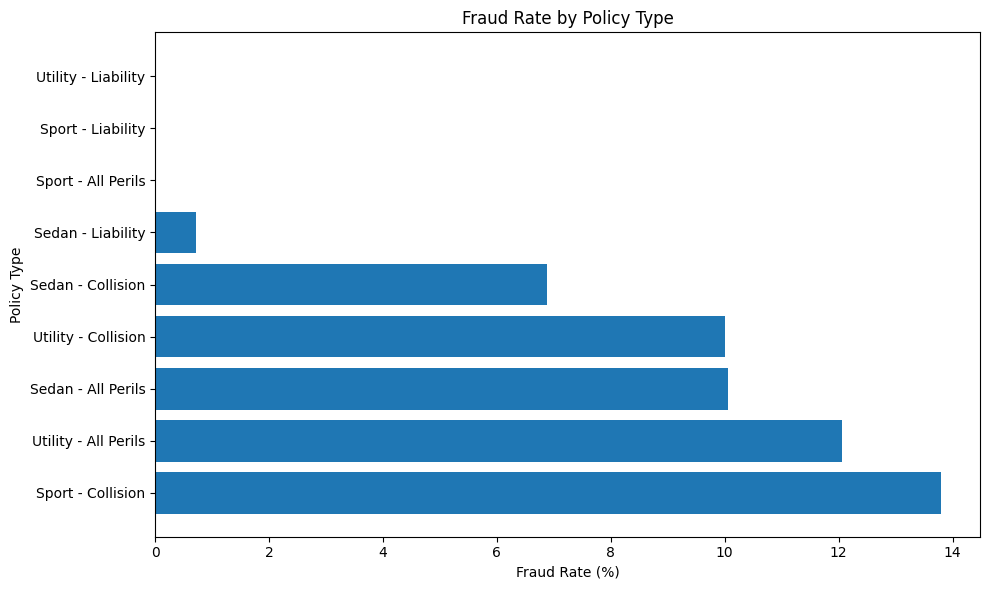

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(
    fraud_by_policy["PolicyType"],
    fraud_by_policy["FraudRate"]
)

plt.title("Fraud Rate by Policy Type")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Policy Type")

plt.tight_layout()
plt.show()


In [37]:
fraud_by_policy


,PolicyType,FraudRate
4,Sport - Collision,13.793103
6,Utility - All Perils,12.058824
0,Sedan - All Perils,10.056276
7,Utility - Collision,10.000000
1,Sedan - Collision,6.876791
2,Sedan - Liability,0.721877
3,Sport - All Perils,0.000000
5,Sport - Liability,0.000000
8,Utility - Liability,0.000000


**check sample size**

In [38]:
policy_counts = (
    df["PolicyType"]
    .value_counts()
    .reset_index()
)

policy_counts.columns = ["PolicyType", "ClaimCount"]

policy_counts

,PolicyType,ClaimCount
0,Sedan - Collision,5584
1,Sedan - Liability,4987
2,Sedan - All Perils,4087
3,Sport - Collision,348
4,Utility - All Perils,340
5,Utility - Collision,30
6,Sport - All Perils,22
7,Utility - Liability,21
8,Sport - Liability,1


In [39]:
df.shape

(15420, 33)

In [40]:
df.dtypes.value_counts()

,count
object,25
int64,7
float64,1


In [41]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound,FraudFlag
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,No,No,External,none,1 year,3 to 4,1994,Liability,No,0
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,Yes,No,External,none,no change,1 vehicle,1994,Collision,No,0
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,No,No,External,none,no change,1 vehicle,1994,Collision,No,0
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No,0
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,No,No,External,none,no change,1 vehicle,1994,Collision,No,0
